Этот пункт предполагает использование простой линейной регрессии применительно к набору данных Auto.
(a) Воспользуйтесь функцией sm.OLS() для построения простой линейной регрессии с переменной mpg в качестве отклика и horsepower в  качестве предиктора. Вызовите функцию summarize()
для вывода результата. Прокомментируйте результирующие
данные, например на основе следующих вопросов:

In [65]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize,poly)
from matplotlib.pyplot import subplots
from statsmodels.stats.anova import anova_lm
import math

Auto = pd.read_csv('data/Auto.csv')
X = pd.DataFrame({'intercept': np.ones(Auto.shape[0]),
                                       'horsepower': Auto['horsepower']})
y = Auto['mpg']

results = sm.OLS(y, X).fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


i) существует ли зависимость между предиктором и откликом?


Да существует (низкое р-значение)

ii) насколько сильна зависимость между предиктором и откликом?


Зависимость достаточно сильная учитывая среднее значение числа лошадиных сил

iii) является ли зависимость между предиктором и откликом
положительной или отрицательной?


Отрицательной

In [14]:
# iv) каким будет значение отклика mpg для значения предиктора horsepower, равного 98? Какими будут 95-процентные
# доверительный интервал и интервал предсказания?
prediction = results.get_prediction([[1, 98]])
print('Predicted value =', prediction.predicted_mean[0])
print('Confidence interval =', prediction.conf_int(alpha=0.05)[0])
print('Confidence interval obs =', prediction.conf_int(alpha=0.05, obs=True)[0])

Predicted value = 24.467077152512424
Confidence interval = [23.97307896 24.96107534]
Confidence interval obs = [14.80939607 34.12475823]


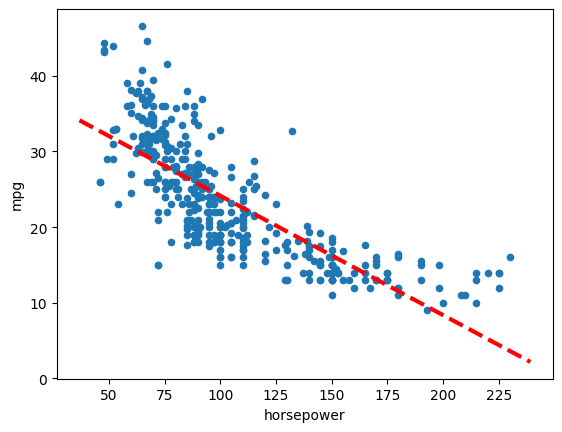

In [16]:
# (b) Постройте график зависимости предиктора и  отклика с  использованием нового объекта ax. Воспользуйтесь методом
# ax.axline() или функцией abline(), показанной в лабораторной
# работе, для отображения регрессионной линии, найденной по
# методу наименьших квадратов.
ax = Auto.plot.scatter('horsepower', 'mpg')

intercept = results.params.intercept
slope = results.params.horsepower

xlim = ax.get_xlim()
ylim = [slope * xlim[0] + intercept, slope * xlim[1] + intercept]

ax.plot(xlim, ylim, 'r--', linewidth=3);

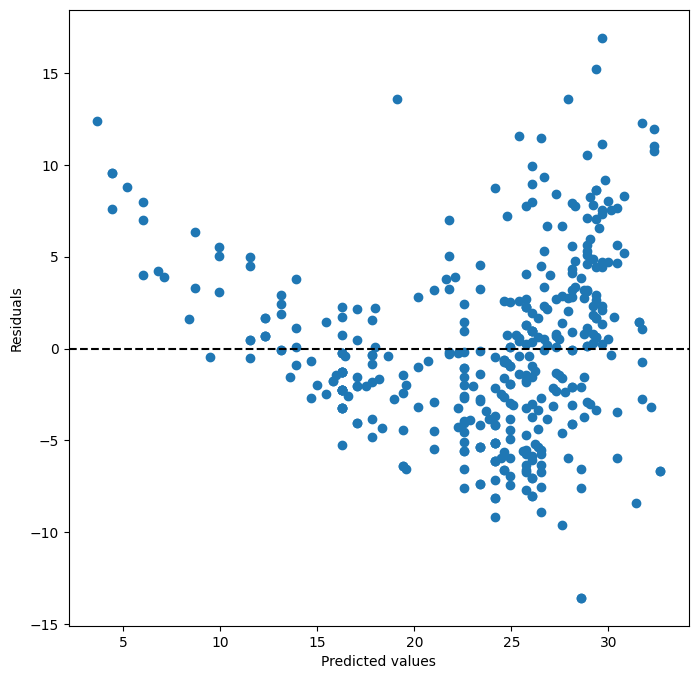

In [17]:
# (c) Постройте несколько диагностических графиков на основе регрессии по методу наименьших квадратов, как было показано
# в  лабораторной работе. Опишите проблемы, обнаруженные
# в этой модели.
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Predicted values')
ax.set_ylabel('Residuals')
ax.axhline(0, c='k', ls='--');

На графике выше есть некая тенденция в форме параболы, что свидетельствует о нелинейности связи между переменной и откликом.

115

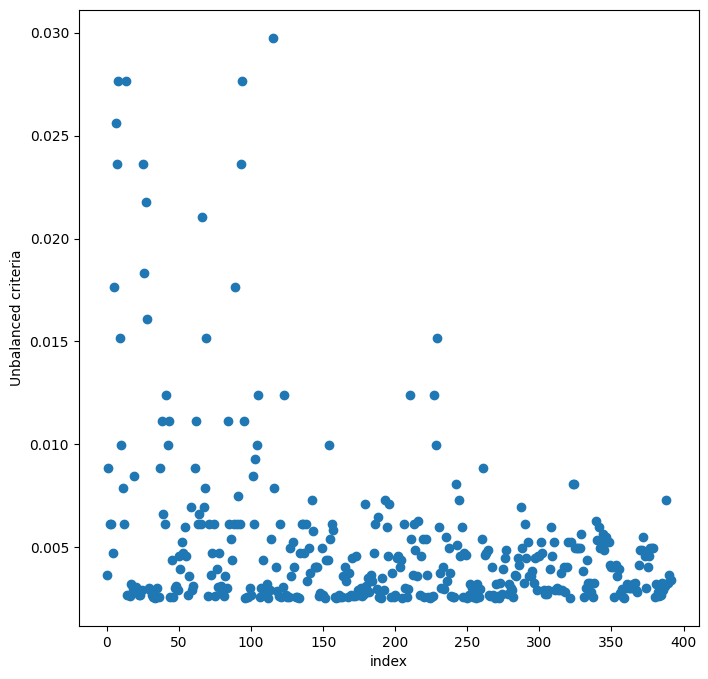

In [40]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('index')
ax.set_ylabel('Unbalanced criteria')
np.argmax(infl.hat_matrix_diag)

Касательно разбалансировки, я конечно не эксперт по данным, но какого-то конкретного аутлаера не вижу, скорее речь идет о группе наблюдений,
которая выделяется из общей массы.

In [41]:
# TASK 9

minus_name = Auto.drop(['name'], axis=1)

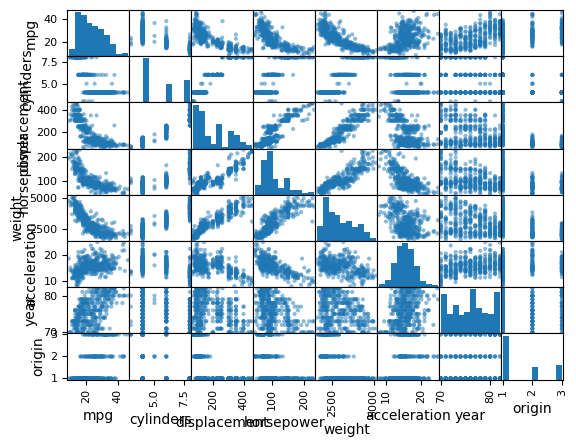

In [42]:
# (a) Постройте матрицу диаграмм рассеяния, включающую все
# переменные из набора данных.
pd.plotting.scatter_matrix(minus_name);

In [43]:
# Рассчитайте корреляционную матрицу для всех переменных,
# воспользовавшись методом DataFrame.corr().

corr = minus_name.corr()
corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [68]:
X = minus_name.drop('mpg', axis = 1)
X['intercept'] = 1

y = Auto['mpg']


model1 = sm.OLS(y, X)

results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000
intercept,-17.2184,4.644,-3.707,0.000


In [55]:
X1 = X.drop('acceleration', axis = 1)

model2 = sm.OLS(y, X1)

results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
cylinders,-0.5067,0.323,-1.570,0.117
displacement,0.0193,0.007,2.579,0.010
horsepower,-0.0239,0.011,-2.205,0.028
weight,-0.0062,0.001,-10.883,0.000
year,0.7475,0.051,14.717,0.000
origin,1.4282,0.278,5.138,0.000
intercept,-15.5635,4.175,-3.728,0.000


In [56]:
anova_lm(results, results1, results2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,390.0,9385.915872,0.0,NaN,NaN,NaN
1,384.0,4252.212530,6.0,5133.703341,77.334698,4.910109e-63
2,385.0,4259.570947,-1.0,-7.358417,0.665088,NaN


Примените функцию sm.OLS() для подгонки множественной линейной регрессии с переменной mpg в качестве отклика и всеми
оставшимися переменными, за исключением name, в качестве
предикторов. Воспользуйтесь функцией summarize() для вывода результатов. Прокомментируйте увиденное. Например:
i) существует ли зависимость между предикторами и откликом? Для ответа воспользуйтесь функцией anova_lm() из
модуля statsmodels;
Ответ - Взаимосвязь между предикторами и откликом в множественной модели скорее всего существует, поскольку практически все p-значения для
коээфициентов модели небольшие, хотя стоит отметить, что по результатам анализа есть сомнения относительно необходимости
использования параметра acceleration в нашей модели (довольно высокого p-значение). Хотя ретья модель без показателя аксилерации показала
не очень уж и более высокий уровень качества, а значит возможно я высосал все из пальца))))


ii) какие предикторы обладают статистически значимой взаимосвязью с откликом?

Ответ - вес и год

iii) о чем говорит коэффициент переменной year?
ответ - год имеет достаточно большое влияе на показатель миль на галлон топлива, причем в положительном смысле, то есть чем больше год,
тем потенциально больше исследуемый показатель (при прочих равных), что кстати более чем логично)

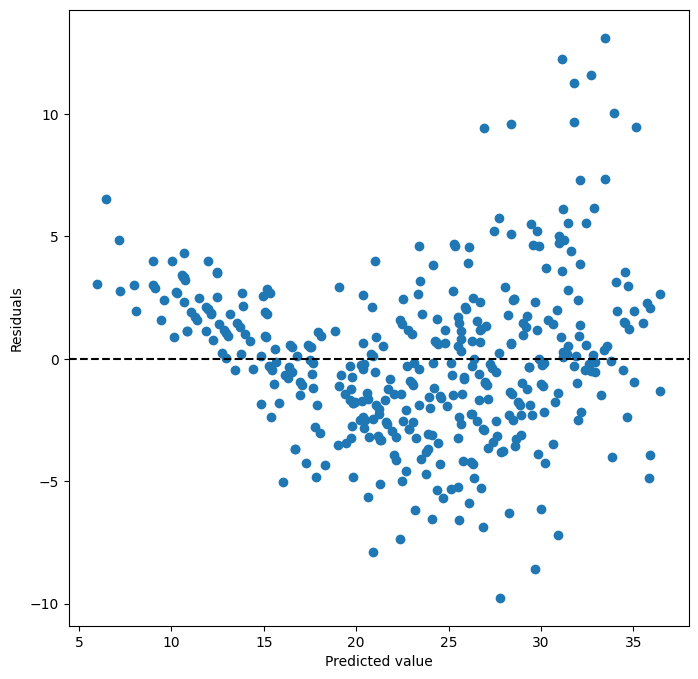

In [57]:
# Постройте несколько диагностических графиков на основе линейной регрессии, как было показано в лабораторной работе.
# Опишите проблемы, обнаруженные в этой модели. Можно ли
# по графикам остатков сделать вывод о наличии сильных выбросов в данных? Существуют ли в исходных данных наблюдения с необычно высокой разбалансировкой?

ax = subplots(figsize=(8,8))[1]
ax.scatter(results2.fittedvalues, results2.resid)
ax.set_xlabel('Predicted value')
ax.set_ylabel('Residuals')
ax.axhline(0, c='k', ls='--')

Не до конца понимаю, что тут еще можно построить, но по графику остатков можно сказать, что нелинейный тренд прослеживается и в множественной
модели, что же касается какой-то разбалансировки или аутлаеров, то каких-то отдельных значений по графику 
не видно, можно лишь заметить, что с ростом предсказанного значения очень сильно вырастает дисперсия остатков, но с ростов в
сторону повышения значения остатков (получается мы чаще занижаем предсказанное значение)

In [69]:
# Выполните несколько подгонок модели с участием эффектов
# взаимодействия, как было описано в  лабораторной работе.
# Есть ли среди этих эффектов статистически значимые?

X2 = X.copy()

X2

# X2['dispalacement-cylinders'] = X2['cylinders'] * X2['displacement']
# X2['dispalacement-horsepower'] = X2['horsepower'] * X2['displacement']
# X2['cylinders-horsepower'] = X2['horsepower'] * X2['cylinders']
# X2['weight-acceleration'] = X2['weight'] * X2['acceleration']
# X2
# model3 = sm.OLS(y, X2)

# results3 = model3.fit()
# summarize(results3)

,cylinders,displacement,horsepower,weight,acceleration,year,origin,intercept
0,8,307.0,130,3504,12.0,70,1,1
1,8,350.0,165,3693,11.5,70,1,1
2,8,318.0,150,3436,11.0,70,1,1
3,8,304.0,150,3433,12.0,70,1,1
4,8,302.0,140,3449,10.5,70,1,1
...,...,...,...,...,...,...,...,...
387,4,140.0,86,2790,15.6,82,1,1
388,4,97.0,52,2130,24.6,82,2,1
389,4,135.0,84,2295,11.6,82,1,1
390,4,120.0,79,2625,18.6,82,1,1


In [59]:
anova_lm(results, results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,390.0,9385.915872,0.0,NaN,NaN,NaN
1,384.0,4252.212530,6.0,5133.703341,101.214238,5.902055e-76
2,380.0,3212.339983,4.0,1039.872548,30.752627,3.432489e-22


Были добавлены некоторые ээфекты взаимодействия между парами, которые потенциально могу зависеть друг от друга.
Если суть по общему сравнению моделей, то модель с эффектами взаимодействия работает лучше, чем без, но интересно,
что потенциально р-значение по показателям объема-числа цилиндров дслшиком высоко, что говорит о возможной излишности
данного эффекта, интересно также, что значительно выросла р-значение для свободного члена.

In [78]:
# (f) Попробуйте использовать в  модели разные преобразования
# переменных, такие как log(X), X или X2
# . Прокомментируйте
# результаты

X3 = X.copy()

X3['log-year'] = X3['year'].apply(lambda x: math.log(float(x)))
X3['pow-weight'] = X3['weight'].apply(lambda x: x ** 2)
X3['sqrt-displacement'] = X3['displacement'].apply(lambda x: math.sqrt(x))
X3
model4 = sm.OLS(y, X3)

results4 = model4.fit()
summarize(results4)

,coef,std err,t,P>|t|
cylinders,0.168900,2.910000e-01,0.581,0.562
displacement,0.082400,2.500000e-02,3.313,0.001
horsepower,-0.051300,1.300000e-02,-4.038,0.000
weight,-0.013400,2.000000e-03,-5.372,0.000
acceleration,-0.013800,8.600000e-02,-0.161,0.872
year,12.479000,1.858000e+00,6.715,0.000
origin,0.514100,2.600000e-01,1.975,0.049
intercept,2967.322900,4.704110e+02,6.308,0.000
log-year,-888.283200,1.412510e+02,-6.289,0.000
pow-weight,0.000001,3.440000e-07,4.121,0.000


In [79]:
anova_lm(results, results1, results4)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,390.0,9385.915872,0.0,NaN,NaN,NaN
1,384.0,4252.212530,6.0,5133.703341,106.725601,1.127669e-78
2,381.0,3054.470133,3.0,1197.742398,49.800220,3.549187e-27


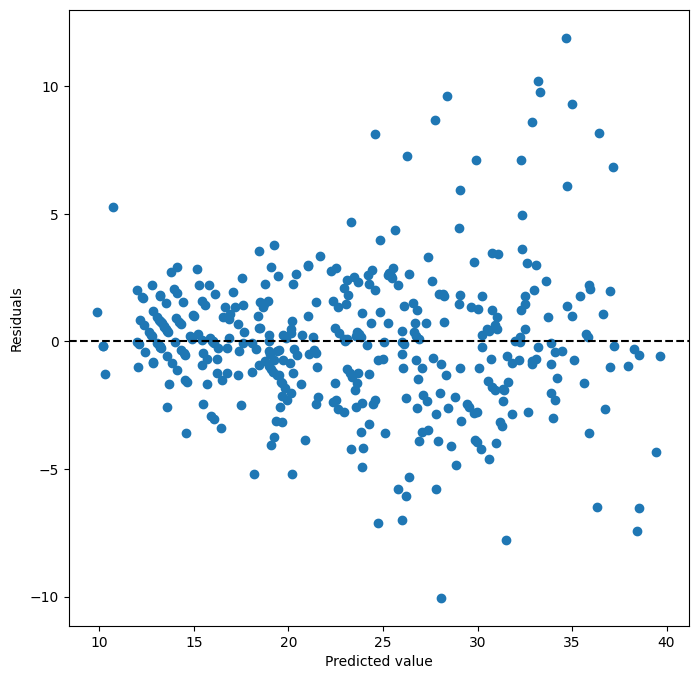

In [80]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results4.fittedvalues, results4.resid)
ax.set_xlabel('Predicted value')
ax.set_ylabel('Residuals')
ax.axhline(0, c='k', ls='--')

Интересно, что по суты хоть выбор значений для преобразования и был скорее интуитивно-рандомным, мы вроде как смогли повысить качество модели
и судя по графику распределения остатков чуть более точно описать реальную функцию f(x) поскольку сейчас мы видим не столь явную тенденцию
к распределению остатков на данном графике, как ранее, при этот сейчас более четка видна група аутлаеров в зоне болешь 10 по уровню остатков.
Вообще p-значения у модифицированных предикторов стремятся к нулю, что якобы сообщает нам о их полезности, да и снижение ошибки тоже намекает на это. 
Возможно есть смысл поэксперементировать с показателями, чтобы добиться более точного предикта

In [85]:
X4 = X.copy()

X4['pow-year'] = X4['year'].apply(lambda x: x ** 2)
X4['pow-weight'] = X4['weight'].apply(lambda x: x ** 2)
X4['sqrt-displacement'] = X4['displacement'].apply(lambda x: math.sqrt(x))
X4
model5 = sm.OLS(y, X4)

results5 = model5.fit()
summarize(results5)
anova_lm(results, results1, results5)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,390.0,9385.915872,0.0,NaN,NaN,NaN
1,384.0,4252.212530,6.0,5133.703341,106.327251,1.761000e-78
2,381.0,3065.913576,3.0,1186.298954,49.140318,7.202102e-27


Не вышло, пошел спать)